# RFC 06 — Interpretation

Review model-native feature importance and risk-probability behavior. Deeper SHAP analysis is deferred until finalist selection.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "peak_risk" / "random_forest"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "peak_risk" / "random_forest"

importance = pd.read_csv(
    REPORTS_DIR / "RFC_06_feature_importance.csv"
)
predictions = pd.read_parquet(
    OUTPUTS_DIR / "random_forest_classifier_validation_predictions.parquet"
)


In [3]:
display(importance.head(25))

,feature,importance
0,target_hour_sin,0.213861
1,origin__Temp (°C),0.166765
2,target_hour,0.128846
3,target_lag_24h,0.105389
4,target_hour_cos,0.033682
5,origin_rolling_mean_24h,0.032305
6,target_month_cos,0.032054
7,target_month_sin,0.031851
8,origin_rolling_std_24h,0.029007
9,target_lag_48h,0.023762


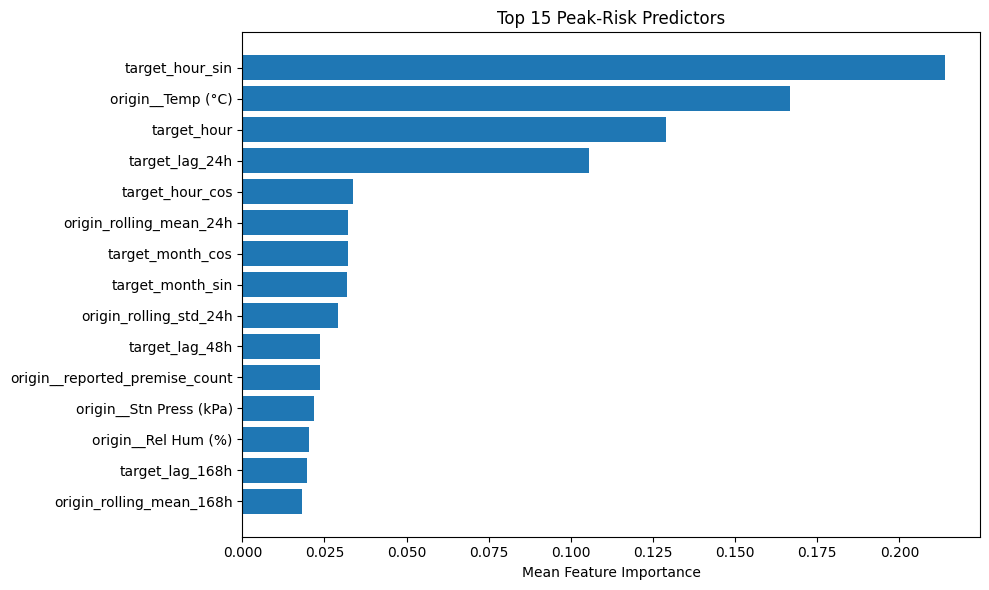

In [4]:
plot_data = importance.head(15).sort_values("importance")
plt.figure(figsize=(10, 6))
plt.barh(plot_data["feature"], plot_data["importance"])
plt.xlabel("Mean Feature Importance")
plt.title("Top 15 Peak-Risk Predictors")
plt.tight_layout()
plt.show()


### Important interpretation note

Tree feature importance is model-specific and is not causal evidence. SHAP should be considered later only for finalist models.